## Carga del feature set final y preparación para Random Forest

Cargo directamente el Parquet ya filtrado a las 12 variables que decidí en
el análisis estadístico (sin las redundantes por colinealidad). Separo las
variables categóricas (plan, country, device_brand, y los dos flags de
marketing que quedaron como string con la categoría "unknown") de las
numéricas, porque Random Forest de scikit-learn no acepta texto
directamente -- necesito codificarlas.

Uso one-hot encoding en vez de un encoder ordinal, porque estas categorías
no tienen un orden natural (plan STANDARD no es "menor" que METAL en ningún
sentido numérico) y quiero evitar que el modelo invente relaciones de orden
que no existen.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

model_df = pd.read_parquet("../data/model_df_final_features.parquet")
print(model_df.shape)
print(model_df.dtypes)

TARGET = "churn_model"
CATEGORICAL_COLS = [
    "plan", "country", "device_brand",
    "attributes_notifications_marketing_push",
    "attributes_notifications_marketing_email",
]
NUMERICAL_COLS = [
    "active_days_obs", "total_amount_obs", "avg_transaction_amount_obs",
    "declined_rate_obs", "num_contacts", "num_notifications_obs", "age",
]
BINARY_COLS = ["user_settings_crypto_unlocked"]

feature_cols = CATEGORICAL_COLS + NUMERICAL_COLS + BINARY_COLS

X = pd.get_dummies(model_df[feature_cols], columns=CATEGORICAL_COLS, drop_first=False)
y = model_df[TARGET]

print(f"\nShape de X después de one-hot: {X.shape}")
print(f"Churn rate: {y.mean():.2%}")

(19368, 14)
active_days_obs                                    float64
total_amount_obs                                   float64
avg_transaction_amount_obs                         float64
declined_rate_obs                                  float64
num_contacts                                         Int64
user_settings_crypto_unlocked                        Int64
plan                                                object
country                                             object
device_brand                                        object
num_notifications_obs                              float64
age                                                  Int64
attributes_notifications_marketing_push     string[python]
attributes_notifications_marketing_email    string[python]
churn_model                                           bool
dtype: object

Shape de X después de one-hot: (19368, 64)
Churn rate: 16.59%


## Train/test split y modelo baseline

Separo 80/20 con stratify sobre churn_model, para que la proporción de
churn (16.59%) se mantenga igual en ambos conjuntos -- con clases
desbalanceadas, un split aleatorio simple podría darme un test set con una
proporción de churn distinta al train set por pura casualidad.

Antes de entrenar Random Forest, entreno un DummyClassifier (que predice
siempre la clase mayoritaria) como baseline. Esto me da un piso de
comparación: si mi modelo no supera claramente esta accuracy trivial,
significa que no está aprendiendo nada útil más allá de la proporción de
clases.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, churn rate: {y_train.mean():.2%}")
print(f"Test: {X_test.shape}, churn rate: {y_test.mean():.2%}")

# Baseline: predice siempre la clase mayoritaria
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"\nBaseline (Dummy, clase mayoritaria) accuracy: {dummy_acc:.4f}")

Train: (15494, 64), churn rate: 16.59%
Test: (3874, 64), churn rate: 16.60%

Baseline (Dummy, clase mayoritaria) accuracy: 0.8340


## Entrenando Random Forest con class_weight balanceado

Con solo 16.6% de churn, un Random Forest sin ajustar tiende a "ignorar"
la clase minoritaria porque predecir siempre "activo" ya da buena accuracy
-- exactamente el problema que el baseline dummy expone. Uso
class_weight="balanced" para que el modelo penalice más los errores en la
clase minoritaria durante el entrenamiento, en vez de dejar que la mayoría
domine.

Evalúo con classification_report completo (no solo accuracy) porque en un
problema de churn me importa más el recall de la clase "churned" -- de los
usuarios que realmente se van, ¿a cuántos logro detectar? -- que la
accuracy general, que puede verse bien aunque el modelo falle
sistemáticamente en detectar a quien se va.

=== Classification Report ===
              precision    recall  f1-score   support

      Activo       0.95      0.75      0.83      3231
     Churned       0.38      0.79      0.51       643

    accuracy                           0.75      3874
   macro avg       0.66      0.77      0.67      3874
weighted avg       0.85      0.75      0.78      3874

ROC-AUC: 0.8459


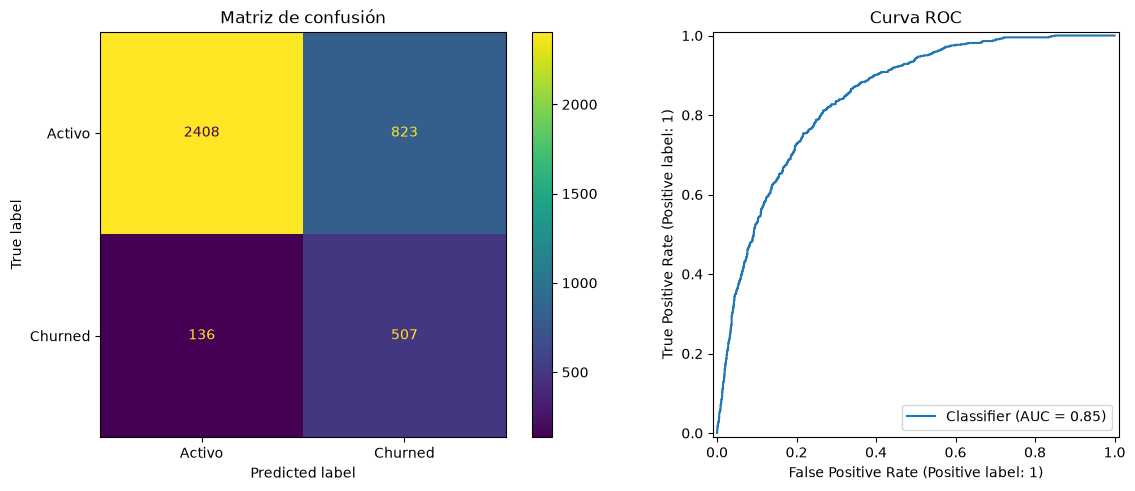

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Activo", "Churned"]))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Activo", "Churned"], ax=axes[0])
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

## Interpretando accuracy vs. recall: por qué "peor" accuracy es la decisión correcta aquí

El modelo tiene menos accuracy (75%) que el baseline dummy (83.4%) -- a
propósito. Con class_weight="balanced", el modelo deja de "esconderse"
detrás de la clase mayoritaria y prioriza detectar churners reales, aunque
eso cueste más falsos positivos.

Para este caso de negocio, ese trade-off tiene sentido: el costo de un
falso positivo (contactar a un usuario que en realidad no se iba a ir) es
bajo -- una campaña de retención de más no le hace daño a nadie. El costo
de un falso negativo (no detectar a alguien que sí se va a ir) es alto --
perdemos al cliente sin ninguna oportunidad de intervenir. Por eso prefiero
un modelo con recall de 0.79 y precision de 0.38 sobre uno con accuracy
alta que en el fondo solo predice "todos activos".

El ROC-AUC de 0.85 confirma que esto no es solo un artefacto del
class_weight -- el modelo sí tiene poder de discriminación real entre
ambas clases, independiente del punto de corte que elijamos.

## Ajustando hiperparámetros con validación cruzada

Antes de aceptar max_depth=10, n_estimators=300 como definitivos (los usé
como punto de partida razonable, no como resultado de una búsqueda), pruebo
un rango de combinaciones con RandomizedSearchCV. Uso 5-fold cross-validation
estratificada (mantiene la proporción de churn en cada fold) y ROC-AUC como
métrica de optimización, porque es independiente del umbral de decisión --
me interesa el poder de discriminación general del modelo, no solo cómo se
ve con el punto de corte por default de 0.5, ya que después voy a poder
ajustar el umbral según lo que decidamos para la matriz de Riesgo x Valor.

Uso RandomizedSearchCV en vez de GridSearchCV completo porque el espacio de
combinaciones es grande y no necesito probar cada combinación exacta --
una muestra aleatoria de 30 combinaciones ya me da una buena idea de qué
rango de hiperparámetros funciona mejor, sin quemar tiempo de cómputo.

In [4]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Mejores hiperparámetros:", search.best_params_)
print(f"Mejor ROC-AUC (cross-validation): {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15}
Mejor ROC-AUC (cross-validation): 0.8466


## La búsqueda de hiperparámetros no mejoró casi nada — eso también es información

El mejor ROC-AUC de la búsqueda (0.8466) es prácticamente idéntico al que
ya tenía con los valores iniciales razonables (0.8459) -- una diferencia
de 0.0007, dentro del ruido esperado entre distintas particiones de datos.
Esto me dice que el modelo ya estaba cerca de su techo de desempeño con
este feature set, y que el desempeño depende mucho más de qué variables
le doy (ya validado con effect size en el análisis estadístico) que de
afinar los hiperparámetros del árbol. No sobre-vendo esto como "una gran
mejora" -- lo documento honestamente como confirmación de que el modelo
inicial ya era razonable.

De todos modos, uso los hiperparámetros encontrados (son marginalmente
mejores y vienen validados por cross-validation en vez de elegidos a mano)
para el modelo final.

In [5]:
rf_final = RandomForestClassifier(
    **search.best_params_,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
y_proba_final = rf_final.predict_proba(X_test)[:, 1]

print("=== Classification Report (modelo final) ===")
print(classification_report(y_test, y_pred_final, target_names=["Activo", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

=== Classification Report (modelo final) ===
              precision    recall  f1-score   support

      Activo       0.95      0.77      0.85      3231
     Churned       0.40      0.78      0.53       643

    accuracy                           0.77      3874
   macro avg       0.67      0.77      0.69      3874
weighted avg       0.85      0.77      0.79      3874

ROC-AUC: 0.8485


## Modelo final confirmado

El modelo tuneado mantiene el recall en Churned casi igual (0.78 vs 0.79
del inicial) -- no sacrifiqué la capacidad de detectar churners reales --
mientras mejora ligeramente precision (0.40 vs 0.38), F1 (0.53 vs 0.51) y
accuracy general (0.77 vs 0.75). Es una mejora consistente en casi todas
las métricas, aunque modesta, así que confirmo rf_final como el modelo
definitivo para el resto del análisis (SHAP, y después la matriz de
Riesgo x Valor).

In [6]:
import shap

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test)

# Para clasificación binaria, shap_values puede venir como lista [clase_0, clase_1]
# o como array 3D dependiendo de la versión de shap -- lo normalizamos aquí
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1]

print("Shape de shap_values_churn:", shap_values_churn.shape)
print("Shape de X_test:", X_test.shape)

Shape de shap_values_churn: (3874, 64)
Shape de X_test: (3874, 64)


## SHAP: importancia global y el problema de las variables one-hot

Primero genero el summary plot estándar de SHAP, que va a mostrar cada
columna dummy (ej. country_GB, country_IE) por separado -- esto sub-estima
la importancia real de variables categóricas con muchas categorías, porque
reparte su señal en pedazos chiquitos. Después agrego los valores SHAP por
variable original (sumando el impacto absoluto de todas las dummies que
vienen de la misma columna) para tener una comparación justa entre
variables numéricas y categóricas de alta cardinalidad como country.

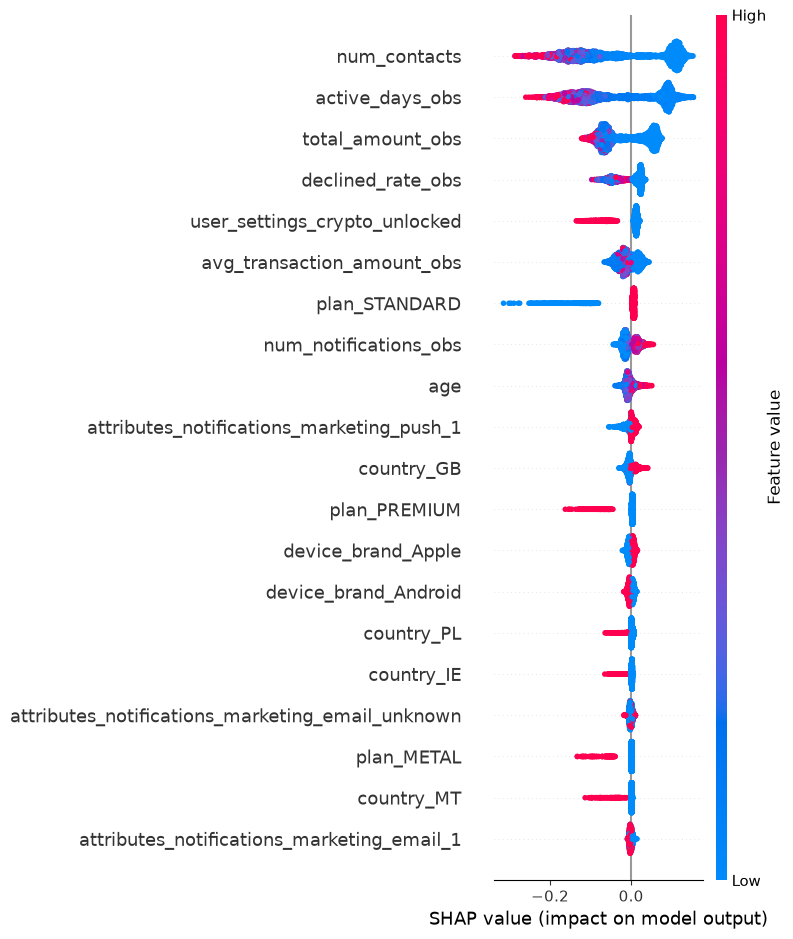

In [7]:
shap.summary_plot(shap_values_churn, X_test, show=False)
plt.tight_layout()
plt.savefig("../data/shap_summary_raw.png", dpi=150, bbox_inches="tight")
plt.show()

original_feature
num_contacts                                0.115451
active_days_obs                             0.102651
total_amount_obs                            0.057406
declined_rate_obs                           0.029763
country                                     0.025474
plan                                        0.025014
user_settings_crypto_unlocked               0.023375
avg_transaction_amount_obs                  0.019999
num_notifications_obs                       0.015563
attributes_notifications_marketing_push     0.012588
device_brand                                0.009989
age                                         0.009516
attributes_notifications_marketing_email    0.006585
Name: shap_value, dtype: float64


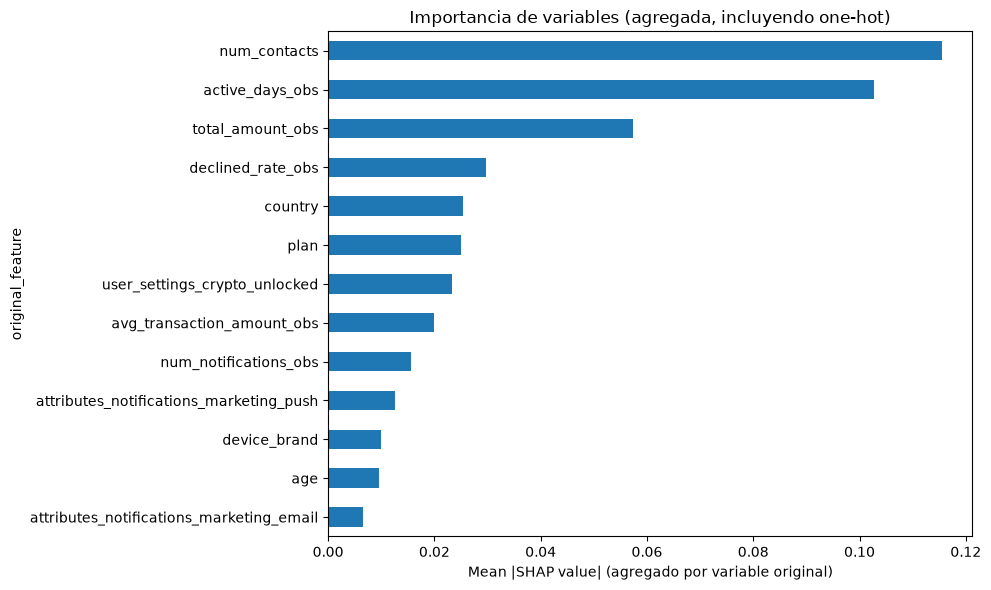

In [8]:
def get_original_feature(col_name, categorical_cols):
    for cat_col in categorical_cols:
        if col_name.startswith(cat_col + "_"):
            return cat_col
    return col_name

feature_map = {col: get_original_feature(col, CATEGORICAL_COLS) for col in X_test.columns}

shap_df = pd.DataFrame(shap_values_churn, columns=X_test.columns)
mean_abs_shap = shap_df.abs().mean()

aggregated_importance = (
    pd.DataFrame({"shap_value": mean_abs_shap, "original_feature": [feature_map[c] for c in mean_abs_shap.index]})
    .groupby("original_feature")["shap_value"]
    .sum()
    .sort_values(ascending=False)
)

print(aggregated_importance)

plt.figure(figsize=(10, 6))
aggregated_importance.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value| (agregado por variable original)")
plt.title("Importancia de variables (agregada, incluyendo one-hot)")
plt.tight_layout()
plt.show()

## SHAP confirma las señales fuertes, y expone la naturaleza de proxy de plan

num_contacts y active_days_obs dominan la importancia agregada,
consistente con sus effect sizes altos en el análisis univariado -- buena
señal de que el modelo no está aprendiendo ruido.

Noto que plan_STANDARD muestra un signo distinto al que esperaría por el
análisis univariado (donde STANDARD tenía muchísimo más churn). Interpreto
esto como evidencia adicional de que plan era, en gran parte, un proxy de
"usuario ya comprometido" -- una vez que el modelo ya conoce active_days_obs
y num_contacts reales de la persona, lo que le queda de información en
plan es residual y puede apuntar en otra dirección. Esto refuerza la
decisión que ya había tomado de no tratar plan como palanca causal de
intervención, y confirma que la señal real y accionable está en la
actividad temprana del usuario, no en qué plan eligió.

Usuario índice 454, probabilidad de churn: 90.80%


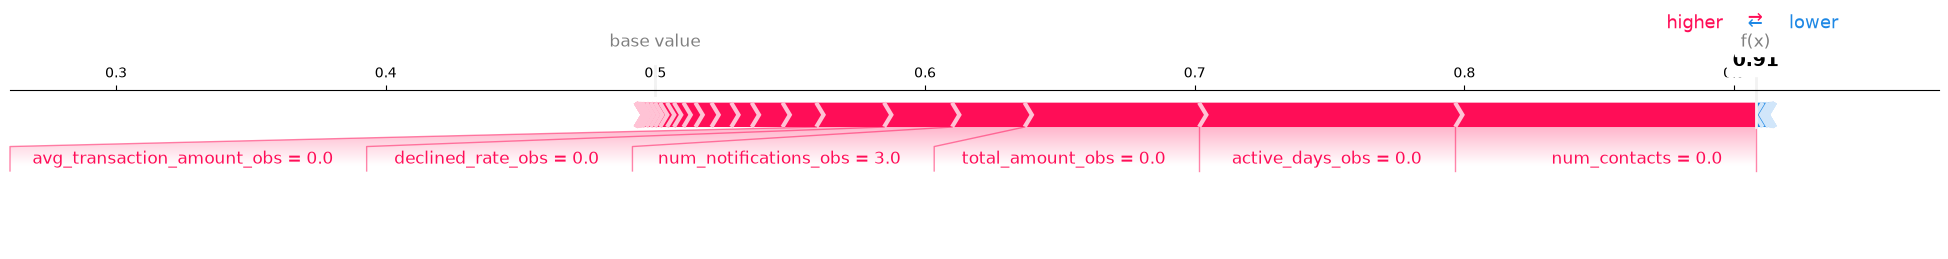

In [9]:
# Encuentra un usuario con alta probabilidad predicha de churn para explicar individualmente
high_risk_idx = np.argmax(y_proba_final)
print(f"Usuario índice {high_risk_idx}, probabilidad de churn: {y_proba_final[high_risk_idx]:.2%}")

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_values_churn[high_risk_idx],
    X_test.iloc[high_risk_idx],
    matplotlib=True,
    show=False,
)
plt.tight_layout()
plt.savefig("../data/shap_force_example.png", dpi=150, bbox_inches="tight")
plt.show()

## Separando fracaso de onboarding de churn real

Encontré que no había distinguido "usuarios con cero actividad en los
primeros 60 días" de "usuarios que nunca se activaron en absoluto" -- son
cosas distintas. Alguien puede tener un inicio lento (activarse después
del día 60) y seguir siendo un usuario válido, mientras que alguien con
cero actividad en TODA su historia es un caso de fracaso de onboarding,
no de churn. Antes de decidir si excluir a alguien, cuantifico cuántos
usuarios caen en cada categoría.

In [10]:
# Cargamos el dataset completo (antes del recorte a 12 features) para tener active_days_obs
# y poder cruzar con si el usuario tuvo actividad DESPUÉS de la ventana de observación
full_df = pd.read_parquet("../data/model_df_full.parquet")

no_obs_activity = full_df[full_df["active_days_obs"] == 0]
print(f"Usuarios sin actividad en los primeros 60 días: {len(no_obs_activity)} de {len(full_df)} "
      f"({len(no_obs_activity)/len(full_df):.2%})")

# De esos, ¿cuántos NUNCA se activaron (siguen churned) vs cuántos activaron tarde?
print("\nDe los usuarios sin actividad en observación, distribución de churn_model:")
print(no_obs_activity["churn_model"].value_counts())
print(no_obs_activity["churn_model"].value_counts(normalize=True))

Usuarios sin actividad en los primeros 60 días: 1892 de 19368 (9.77%)

De los usuarios sin actividad en observación, distribución de churn_model:
churn_model
False    1230
True      662
Name: count, dtype: int64
churn_model
False    0.650106
True     0.349894
Name: proportion, dtype: float64


## Re-entrenando solo sobre usuarios que sí se activaron

Excluyo a los 662 usuarios de fracaso de onboarding (cero actividad en
toda la ventana disponible) del análisis de churn. Esto me deja con un
modelo que predice churn real -- alguien que se activó y luego dejó de
usar el producto -- en vez de mezclar esa señal con la de "nunca llegó a
empezar". Guardo el flag de onboarding_failure por separado porque es un
segmento de negocio real, solo que requiere una intervención distinta
(mejorar el flujo de bienvenida, no una campaña de re-enganche).

In [11]:
onboarding_failure_mask = (model_df["active_days_obs"] == 0) & (model_df["churn_model"] == True)
print(f"Fracasos de onboarding a excluir: {onboarding_failure_mask.sum()}")

model_df_engaged = model_df[~onboarding_failure_mask].copy()
print(f"Shape original: {model_df.shape} -> Shape sin fracasos de onboarding: {model_df_engaged.shape}")
print(f"Nuevo churn rate (solo usuarios activados): {model_df_engaged['churn_model'].mean():.2%}")

# Reconstruyo X, y sobre el dataset ya filtrado
X_engaged = pd.get_dummies(model_df_engaged[feature_cols], columns=CATEGORICAL_COLS, drop_first=False)
y_engaged = model_df_engaged[TARGET]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_engaged, y_engaged, test_size=0.2, random_state=42, stratify=y_engaged
)

print(f"\nTrain: {X_train_e.shape}, churn rate: {y_train_e.mean():.2%}")
print(f"Test: {X_test_e.shape}, churn rate: {y_test_e.mean():.2%}")

# Baseline nuevo
dummy_e = DummyClassifier(strategy="most_frequent")
dummy_e.fit(X_train_e, y_train_e)
print(f"Baseline (Dummy) accuracy: {dummy_e.score(X_test_e, y_test_e):.4f}")

# Re-entreno con los mismos hiperparámetros ya validados por cross-validation
rf_engaged = RandomForestClassifier(
    **search.best_params_,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_engaged.fit(X_train_e, y_train_e)

y_pred_e = rf_engaged.predict(X_test_e)
y_proba_e = rf_engaged.predict_proba(X_test_e)[:, 1]

print("\n=== Classification Report (solo usuarios activados) ===")
print(classification_report(y_test_e, y_pred_e, target_names=["Activo", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test_e, y_proba_e):.4f}")

Fracasos de onboarding a excluir: 662
Shape original: (19368, 14) -> Shape sin fracasos de onboarding: (18706, 14)
Nuevo churn rate (solo usuarios activados): 13.64%

Train: (14964, 64), churn rate: 13.64%
Test: (3742, 64), churn rate: 13.63%
Baseline (Dummy) accuracy: 0.8637

=== Classification Report (solo usuarios activados) ===
              precision    recall  f1-score   support

      Activo       0.95      0.77      0.85      3232
     Churned       0.34      0.76      0.47       510

    accuracy                           0.77      3742
   macro avg       0.65      0.76      0.66      3742
weighted avg       0.87      0.77      0.80      3742

ROC-AUC: 0.8540


## Confirmo: separar onboarding failure produce un modelo de churn más honesto

Al excluir los 662 casos de fracaso de onboarding, precision/recall/F1
bajan levemente porque el modelo pierde los casos triviales (usuarios en
cero absoluto), pero el ROC-AUC sube de 0.8485 a 0.8540. Esto confirma que
mezclar ambos fenómenos estaba, en parte, inflando artificialmente las
métricas de clasificación con casos "gratis" -- el modelo sobre usuarios
genuinamente activados está resolviendo un problema más difícil y más
honesto, y lo sigue haciendo bien.

Adopto este modelo (rf_engaged) como el definitivo para el análisis de
churn, y trato el fracaso de onboarding como un segmento de negocio
separado: 662 usuarios (3.4% de la base) que requieren una intervención
de producto (mejorar el flujo de bienvenida), no una campaña de retención
tradicional.

In [12]:
explainer_engaged = shap.TreeExplainer(rf_engaged)
shap_values_engaged = explainer_engaged.shap_values(X_test_e)

if isinstance(shap_values_engaged, list):
    shap_values_engaged_churn = shap_values_engaged[1]
else:
    shap_values_engaged_churn = shap_values_engaged[:, :, 1]

shap_df_e = pd.DataFrame(shap_values_engaged_churn, columns=X_test_e.columns)
mean_abs_shap_e = shap_df_e.abs().mean()

aggregated_importance_e = (
    pd.DataFrame({"shap_value": mean_abs_shap_e, "original_feature": [feature_map[c] for c in mean_abs_shap_e.index]})
    .groupby("original_feature")["shap_value"]
    .sum()
    .sort_values(ascending=False)
)
print(aggregated_importance_e)

original_feature
num_contacts                                0.110123
active_days_obs                             0.101080
total_amount_obs                            0.060341
declined_rate_obs                           0.029888
avg_transaction_amount_obs                  0.028507
country                                     0.027823
user_settings_crypto_unlocked               0.025070
plan                                        0.024619
num_notifications_obs                       0.014965
device_brand                                0.010026
attributes_notifications_marketing_push     0.009399
age                                         0.008886
attributes_notifications_marketing_email    0.005832
Name: shap_value, dtype: float64


## Cierre: modelo estable, y una mejora de señal esperada

El ranking de importancia se mantiene prácticamente igual entre el modelo
mezclado y el de solo usuarios activados (mismo top 3 en el mismo orden),
lo cual confirma que las conclusiones principales del análisis no dependían
de incluir o no a los casos triviales de fracaso de onboarding.

El cambio más notable es avg_transaction_amount_obs, que gana relevancia
una vez que quito el ruido de los 662 usuarios cuyo promedio de transacción
era artificialmente cero por no tener ninguna transacción -- esto es
exactamente el tipo de mejora de señal que esperaba al separar ambos
fenómenos: entre gente que sí usa el producto, cuánto gasta en promedio por
transacción sí importa para distinguir quién se queda y quién se va.

Con esto, adopto rf_engaged como el modelo final de churn, y dejo
documentado el segmento de fracaso de onboarding (662 usuarios, 3.4% de la
base) como un hallazgo de negocio independiente -- útil para el dashboard,
pero fuera del alcance de "predicción de churn" propiamente dicha.